In [1]:
#imports & settings

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False)

In [2]:
#load all 8 samples

import gc

data_dir = Path("../data")
sample_dirs = sorted([
    p for p in data_dir.iterdir()
    if p.is_dir() and (p / "matrix.mtx.gz").exists()
])

adatas = {}
for sample_path in sample_dirs:
    sample_name = sample_path.name
    a = sc.read_10x_mtx(path=sample_path, var_names="gene_symbols", cache=False)

    parts = sample_name.split("_")
    a.obs["sample"] = sample_name
    a.obs["sex"] = parts[0]
    a.obs["treatment"] = parts[1]
    a.obs["replicate"] = parts[2]
    a.obs["condition"] = f"{parts[0]}_{parts[1]}"

    # Filter EACH sample individually before merging — keeps peak memory much lower
    sc.pp.filter_cells(a, min_genes=200)
    sc.pp.filter_genes(a, min_cells=3)

    adatas[sample_name] = a
    print(f"{sample_name}: {a.n_obs} cells x {a.n_vars} genes (post per-sample filter)")

adata = ad.concat(adatas, label="sample_batch", index_unique="-", join="outer", fill_value=0)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.notna()].copy()
del adatas
gc.collect()
print(f"Merged Dataset: {adata.n_obs} cells x {adata.n_vars} genes")

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 7024 genes that are detected in less than 3 cells
Female_Cocaine_1: 13072 cells x 10457 genes (post per-sample filter)
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 5 cells that have less than 200 genes expressed
filtered out 6630 genes that are detected in less than 3 cells
Female_Cocaine_2: 9362 cells x 10851 genes (post per-sample filter)
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 4 cells that have less than 200 genes expressed
filtered out 7273 genes that are detected in less than 3 cells
Female_Sucrose_1: 9068 cells x 10208 genes (post per-sample filter)
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 7132 genes that are

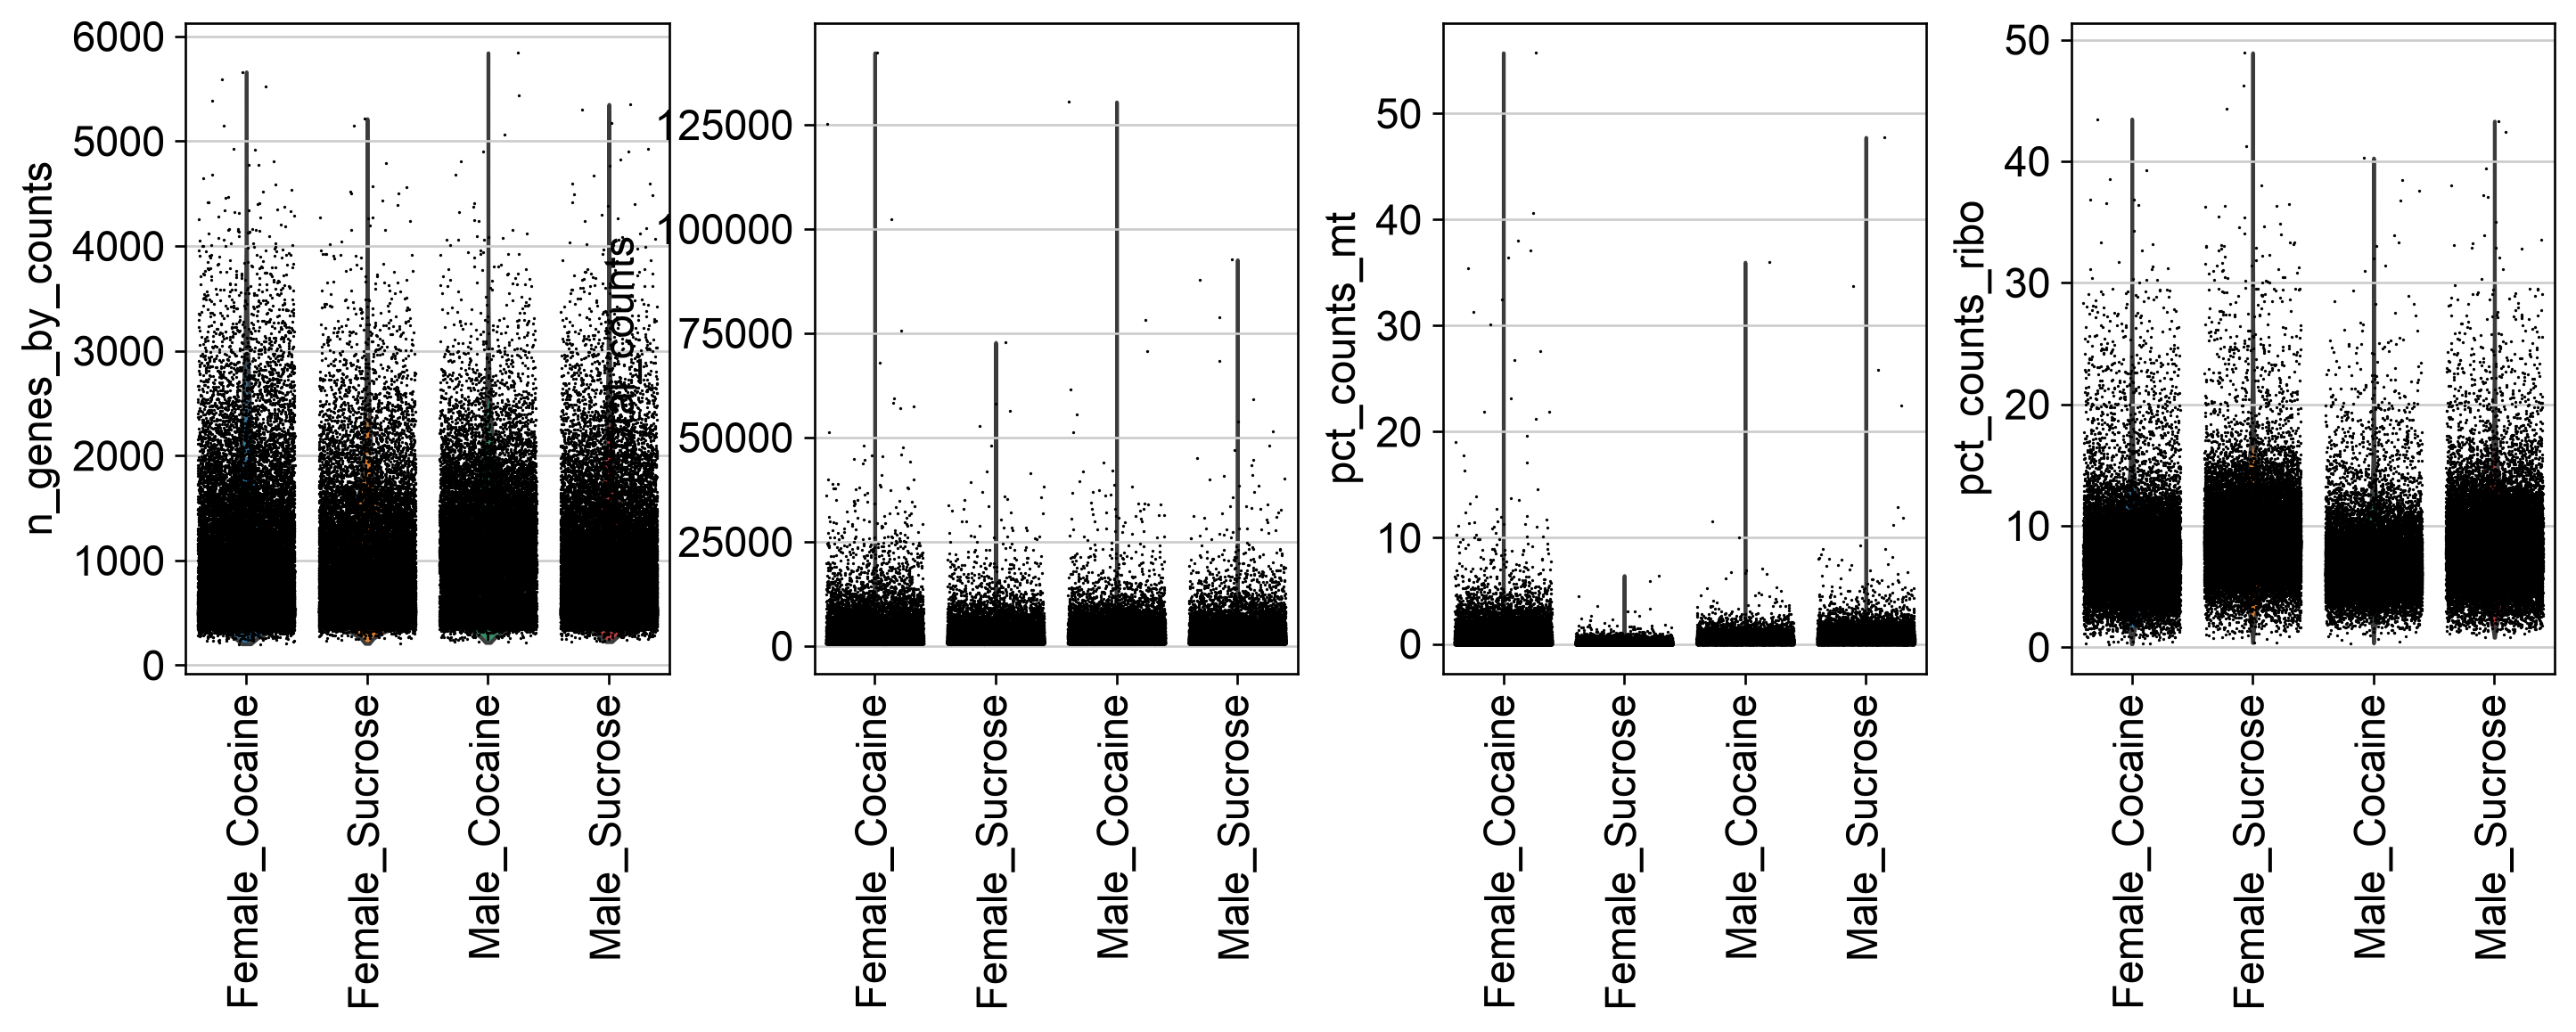

In [3]:
#QC metrics (Drosophila-specific prefixes)

sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False, figsize=(3.5, 4))
adata.var["mt"] = adata.var_names.astype(str).str.startswith("mt:")
adata.var["ribo"] = adata.var_names.astype(str).str.startswith(("RpS", "RpL", "rps", "rpl"))

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True
)

sc.settings.figdir = "../results/figures/"

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    groupby="condition",
    jitter=0.4,
    multi_panel=True,
    rotation=90,
    save="_qc_violin.png"
)

In [4]:
#filter cells/genes

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 10.0, :].copy()
print(f"Cells remaining after QC: {adata.n_obs}")

Cells remaining after QC: 88923


In [5]:
#normalization

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
adata = adata[:, adata.var.highly_variable].copy()
gc.collect()

# regress_out skipped — too memory-heavy for 7.2GB RAM; disclose this in Methods
sc.pp.scale(adata, max_value=10)
gc.collect()

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:05)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/home/tanvir-ahmed/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


24456

In [6]:
adata.write("../results/adata_qc_normalized.h5ad")